In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from sklearn import preprocessing as p

## Cleaning data

In [2]:
#importing data from Modulair MOD-000681
winddata = pd.read_csv('MOD-00680-3-11data.csv').set_index('timestamp')
winddata.head()

,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,bin4,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-31T23:59:39Z,577611124,2025-12-31T18:59:39Z,MOD-00680,50.3,-0.3,5.994,0.655,0.205,0.049,0.032,...,30.679,26.285,14313.0,14314.0,14315.0,14467.0,14492.0,14542.0,14517.0,6.15
2025-12-31T23:58:39Z,577611126,2025-12-31T18:58:39Z,MOD-00680,50.5,-0.4,6.468,0.764,0.280,0.051,0.046,...,32.084,24.489,14313.0,14314.0,14315.0,14467.0,14492.0,14542.0,14517.0,4.76
2025-12-31T23:57:39Z,577611127,2025-12-31T18:57:39Z,MOD-00680,50.4,-0.4,6.272,0.729,0.231,0.060,0.029,...,31.378,24.855,14313.0,14314.0,14315.0,14467.0,14492.0,14542.0,14517.0,4.84
2025-12-31T23:56:39Z,577611125,2025-12-31T18:56:39Z,MOD-00680,50.2,-0.4,5.740,0.710,0.181,0.061,0.035,...,31.386,25.938,14313.0,14314.0,14315.0,14467.0,14492.0,14542.0,14517.0,6.67
2025-12-31T23:55:39Z,577609083,2025-12-31T18:55:39Z,MOD-00680,50.7,-0.4,6.041,0.714,0.229,0.063,0.039,...,31.602,24.821,14313.0,14314.0,14315.0,14467.0,14492.0,14542.0,14517.0,4.88


In [3]:
#only columns of interest
COLS_TO_INCLUDE = ['timestamp_local','wd','ws']
winddata = winddata[COLS_TO_INCLUDE]

winddata.head()

,timestamp_local,wd,ws
timestamp,,,
2025-12-31T23:59:39Z,2025-12-31T18:59:39Z,221.4,5.93
2025-12-31T23:58:39Z,2025-12-31T18:58:39Z,222.7,4.41
2025-12-31T23:57:39Z,2025-12-31T18:57:39Z,197.9,3.36
2025-12-31T23:56:39Z,2025-12-31T18:56:39Z,217.4,6.24
2025-12-31T23:55:39Z,2025-12-31T18:55:39Z,221.5,4.66


In [4]:
#removing the UTC time
winddata = winddata.reset_index(drop = True)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-31T18:59:39Z,221.4,5.93
1,2025-12-31T18:58:39Z,222.7,4.41
2,2025-12-31T18:57:39Z,197.9,3.36
3,2025-12-31T18:56:39Z,217.4,6.24
4,2025-12-31T18:55:39Z,221.5,4.66


In [5]:
#converting to datetime
winddata['timestamp_local'] = pd.to_datetime(winddata['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-31 18:59:39,221.4,5.93
1,2025-12-31 18:58:39,222.7,4.41
2,2025-12-31 18:57:39,197.9,3.36
3,2025-12-31 18:56:39,217.4,6.24
4,2025-12-31 18:55:39,221.5,4.66


In [6]:
#taking hourly average of df. round to floor of the hour
winddata = winddata.groupby(winddata['timestamp_local'].dt.floor('h')).agg(wd = ('wd','mean'),
                                                                           ws = ('ws','mean')).reset_index()

winddata = winddata.round(decimals = 2)
winddata = winddata.dropna()
winddata

,timestamp_local,wd,ws
0,2025-03-31 20:00:00,128.81,3.76
1,2025-03-31 21:00:00,187.42,2.76
2,2025-03-31 22:00:00,240.47,4.41
3,2025-03-31 23:00:00,243.02,11.68
4,2025-04-01 00:00:00,269.82,2.98
...,...,...,...
6463,2025-12-31 14:00:00,268.82,7.27
6464,2025-12-31 15:00:00,264.57,6.84
6465,2025-12-31 16:00:00,262.70,5.18
6466,2025-12-31 17:00:00,247.28,3.41


In [7]:
ts = pd.read_csv('MOD-000680_timeseries_hourly_scaled.csv').reset_index()
ts.head()

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,0,2025-03-31 20:00:00,0.537031,0.685166,0.316643,0.033910,0.284336,0.101296,0.073262,0.086003,0.132827,0.293478
1,1,2025-03-31 21:00:00,0.522884,0.651614,0.333517,0.044154,0.319940,0.174254,0.098396,0.101180,0.151803,0.364130
2,2,2025-03-31 22:00:00,0.556833,0.735387,0.312893,0.049629,0.316261,0.264697,0.131551,0.118044,0.153700,0.315217
3,3,2025-03-31 23:00:00,0.421759,0.419076,0.544833,0.043448,0.138538,0.086825,0.044920,0.038786,0.049336,0.092391
4,4,2025-04-01 00:00:00,0.410638,0.560878,0.516709,0.042918,0.173048,0.112150,0.058289,0.050590,0.060721,0.114130


In [8]:
results = pd.read_csv('680_factor_results.csv')
results.head()

,timestamp_local,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-03-31 20:00:00,0.062073,0.057488,0.079925,0.036522
1,2025-03-31 21:00:00,0.056460,0.065106,0.108501,0.042440
2,2025-03-31 22:00:00,0.063930,0.072245,0.119402,0.030952
3,2025-03-31 23:00:00,0.037907,0.021704,0.032941,0.102868
4,2025-04-01 00:00:00,0.049351,0.026138,0.043470,0.083632


## Merging dataframes

In [9]:
data_1_2 = pd.merge(ts, results, on = 'timestamp_local', how = 'inner')
data_1_2

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4
0,0,2025-03-31 20:00:00,0.537031,0.685166,0.316643,0.033910,0.284336,0.101296,0.073262,0.086003,0.132827,0.293478,0.062073,0.057488,0.079925,0.036522
1,1,2025-03-31 21:00:00,0.522884,0.651614,0.333517,0.044154,0.319940,0.174254,0.098396,0.101180,0.151803,0.364130,0.056460,0.065106,0.108501,0.042440
2,2,2025-03-31 22:00:00,0.556833,0.735387,0.312893,0.049629,0.316261,0.264697,0.131551,0.118044,0.153700,0.315217,0.063930,0.072245,0.119402,0.030952
3,3,2025-03-31 23:00:00,0.421759,0.419076,0.544833,0.043448,0.138538,0.086825,0.044920,0.038786,0.049336,0.092391,0.037907,0.021704,0.032941,0.102868
4,4,2025-04-01 00:00:00,0.410638,0.560878,0.516709,0.042918,0.173048,0.112150,0.058289,0.050590,0.060721,0.114130,0.049351,0.026138,0.043470,0.083632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,6413,2025-12-31 14:00:00,0.434716,0.633678,0.323370,0.033557,0.070811,0.021103,0.012299,0.008432,0.005693,0.010870,0.062304,0.014804,0.000000,0.036442
6414,6414,2025-12-31 15:00:00,0.438226,0.642330,0.315540,0.036913,0.066534,0.020802,0.011765,0.008432,0.007590,0.010870,0.063326,0.014383,0.000000,0.034237
6415,6415,2025-12-31 16:00:00,0.462462,0.655202,0.292820,0.042388,0.076778,0.026229,0.014973,0.010118,0.007590,0.010870,0.065031,0.019549,0.000000,0.029110
6416,6416,2025-12-31 17:00:00,0.492552,0.668917,0.268667,0.035500,0.083342,0.028640,0.016043,0.011804,0.009488,0.016304,0.067026,0.024042,0.000368,0.023971


In [10]:
data_1_2['timestamp_local'] = pd.to_datetime(data_1_2['timestamp_local'])

In [11]:
data = pd.merge(data_1_2, winddata, on = 'timestamp_local', how = 'inner')
data

,index,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4,wd,ws
0,0,2025-03-31 20:00:00,0.537031,0.685166,0.316643,0.033910,0.284336,0.101296,0.073262,0.086003,0.132827,0.293478,0.062073,0.057488,0.079925,0.036522,128.81,3.76
1,1,2025-03-31 21:00:00,0.522884,0.651614,0.333517,0.044154,0.319940,0.174254,0.098396,0.101180,0.151803,0.364130,0.056460,0.065106,0.108501,0.042440,187.42,2.76
2,2,2025-03-31 22:00:00,0.556833,0.735387,0.312893,0.049629,0.316261,0.264697,0.131551,0.118044,0.153700,0.315217,0.063930,0.072245,0.119402,0.030952,240.47,4.41
3,3,2025-03-31 23:00:00,0.421759,0.419076,0.544833,0.043448,0.138538,0.086825,0.044920,0.038786,0.049336,0.092391,0.037907,0.021704,0.032941,0.102868,243.02,11.68
4,4,2025-04-01 00:00:00,0.410638,0.560878,0.516709,0.042918,0.173048,0.112150,0.058289,0.050590,0.060721,0.114130,0.049351,0.026138,0.043470,0.083632,269.82,2.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413,6413,2025-12-31 14:00:00,0.434716,0.633678,0.323370,0.033557,0.070811,0.021103,0.012299,0.008432,0.005693,0.010870,0.062304,0.014804,0.000000,0.036442,268.82,7.27
6414,6414,2025-12-31 15:00:00,0.438226,0.642330,0.315540,0.036913,0.066534,0.020802,0.011765,0.008432,0.007590,0.010870,0.063326,0.014383,0.000000,0.034237,264.57,6.84
6415,6415,2025-12-31 16:00:00,0.462462,0.655202,0.292820,0.042388,0.076778,0.026229,0.014973,0.010118,0.007590,0.010870,0.065031,0.019549,0.000000,0.029110,262.70,5.18
6416,6416,2025-12-31 17:00:00,0.492552,0.668917,0.268667,0.035500,0.083342,0.028640,0.016043,0.011804,0.009488,0.016304,0.067026,0.024042,0.000368,0.023971,247.28,3.41


## Plots

In [12]:
wd_rad = np.radians(np.array(data['wd'])) #deg to rad
ws = np.array(data['ws']) #m/s
Factor1 = np.array(data['Factor 1'])
Factor2 = np.array(data['Factor 2'])
Factor3 = np.array(data['Factor 3'])

In [13]:
WD, WS = np.meshgrid(np.linspace(0, 2*np.pi, 36), np.linspace(min(ws), max(ws), 16 ))
Z1 = interpolate.griddata((wd_rad, ws), Factor1, (WD, WS), method='linear')
Z2 = interpolate.griddata((wd_rad, ws), Factor2, (WD, WS), method='linear')
Z3 = interpolate.griddata((wd_rad, ws), Factor3, (WD, WS), method='linear')

Z1 = np.nan_to_num(Z1, nan=1e-3)
Z2 = np.nan_to_num(Z2, nan=1e-3)
Z3 = np.nan_to_num(Z3, nan=1e-3)

In [14]:
maxima = [np.max(i) for i in [Z1,Z2,Z3]]
maxima

[np.float64(0.07708952610396932),
 np.float64(0.10727343465198264),
 np.float64(0.330421089166357)]

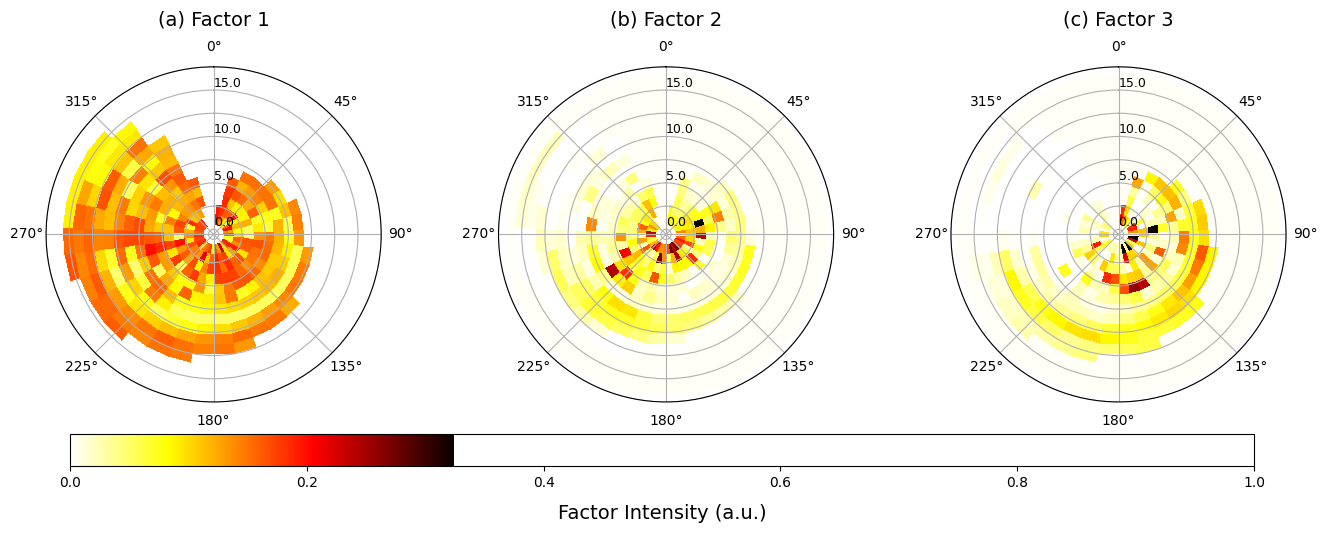

In [16]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 16), subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace=0.35)
cmap = plt.get_cmap('hot_r')
cmap.set_under('none')

#change set-up to compass bearings
for i in range(3):
    ax[i].set_theta_zero_location('N')
    ax[i].set_theta_direction(-1)

#label
ax[0].set_title('(a) Factor 1',fontsize=14, y=1.10)
ax[1].set_title('(b) Factor 2',fontsize=14, y=1.10)
ax[2].set_title('(c) Factor 3',fontsize=14, y=1.10)

#plot
img1 = ax[0].pcolormesh(WD, WS, Z1, cmap=cmap, vmax = np.max(Z2))
img2 = ax[1].pcolormesh(WD, WS, Z2, cmap=cmap, vmax = np.max(Z2))
img3 = ax[2].pcolormesh(WD, WS, Z3, cmap=cmap, vmax = np.max(Z2))

#label radial ticks
for i in range(3):
    ax[i].tick_params(axis='y', which='major', labelsize=9)
    ax[i].set_rticks([0,2.5,5,7.5,10,12.5,15,17.5])
    ax[i].set_rlabel_position(0)
    ax[i].set_yticklabels(['0.0','','5.0','','10.0','','15.0',''])

#set colorbar
cbar_ax = fig.add_axes([0.14, 0.35, 0.74, 0.02])
cbar = fig.colorbar(img3, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks(list(np.linspace(0, np.max(Z3), 6)))
cbar.set_ticklabels([0.0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label('Factor Intensity (a.u.)', labelpad = 10, fontsize = 14)
cbar.ax.xaxis.set_label_position('bottom')

fig.savefig('windrose_MOD-00680.png')